In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
%gui qt5

In [3]:
import pyLCOS

In [4]:
import sys
win_home_module_path = r'C:\\LAB\\Coding\\Python\\MODULES'
sys.path.insert(1, win_home_module_path)
import mark_lib as mkl
import holography as holo
t = mkl.times

### IMPORT ZERNIKES MODULE AND CREATE THEM FROM MODELAB

In [5]:
z = holo.Zernikes(max_zernike_radial_number=6, mask_size_x_in_pixels=960, mask_size_y_in_pixels=960)

### SOME MODES MASKS

In [ ]:
import h5py
import hdf5storage
path_to_modes = "C:\LAB\Coding\Python\Data\SLM_MASKS\MODELIBRARY_Fibre_GradedIndex_1300nm_DEBUG.mat"
data = hdf5storage.loadmat(path_to_modes) # it loads data as a dictionary
data.keys()
modesMasks = angle(data['ILLUMINATION'][:,1024//2-480:1024//2+480,1024//2-480:1024//2+480,])
modesMasks.shape

### CREATE LCOS OBJECT (PASSING ZERNIKES)

In [6]:
slm = pyLCOS.LCOS(screen=1, mask_size=(960,960), zernikeH = angle(z.field_h), zernikeV = angle(z.field_v))

1152 1920


In [7]:
t.tic()
Hcenter = [586,537]
Vcenter = [1398,535]
slm.setCenters(Hcenter,Vcenter)
t.toc()

Elapsed time =  0.05385541915893555


0.05385541915893555

### BUNCH OF MASK SETTING AND SETTING DISPLAY MASK

In [49]:
slm.mask_specs['H']['att_enabled'] = 1
slm.mask_specs['H']['attWeight'] = 0.5
slm.mask_specs['V']['att_enabled'] = 0
slm.mask_specs['V']['attWeight'] = 60
slm.mask_specs['H']['pattern'] = modesMasks[1]
slm.mask_specs['V']['pattern'] = modesMasks[0]

slm.patternEnabled = 0
slm.zernikesEnabled = 0

slm.setmask(pol = 'H')
slm.refreshfreq #check refreshrate.

15.426417203953054

## OTHER STUFF (DEBUGGING)

In [33]:
for i in range(6):
    #t.tic()
    slm.mask_specs['H']['pattern'] = modesMasks[i]
    slm.mask_specs['V']['pattern'] = modesMasks[5-i]
    slm.setmask(pol = 'HV')
    #t.toc()
    

In [10]:
slm.mask_specs['V']['centers'] = [1397,535]

In [12]:
slm.offset_center = 0
slm.defineCenters()
slm.calcApertures()
slm.setmask(pol = 'V')
print(slm.Hcenter, slm.Vcenter)


[586, 614] [1397, 616]


In [112]:
def binarycheckboard(width, height, spatial_frequency, scale=1, offset = False ,pol = 'HV'):
    y = np.arange(height, dtype = np.float64)#linspace(0,2*pi,1080)
    x = np.arange(width, dtype = np.float64)
    X,Y = np.meshgrid(x,y)
    
    GY = (((Y*spatial_frequency)%(1.0)>=.5)*scale).astype(np.float64)
    GX = (((X*spatial_frequency)%(1.0)>=.5)*scale).astype(np.float64)
     
    chBoard = abs(GX - GY)
    
    if offset == True:
        offset = scale/2
        chBoard -= offset
    
    if pol == 'H':
        chBoard[:,int(x.max()//2):-1] = 0
    elif pol == 'V':
        chBoard[:,0:int(x.max()//2)] = 0

    return(chBoard,GX,GY)

In [113]:
checker, GX, GY = binarycheckboard(960, 960, spatial_frequency = 1/100, scale=1, offset = True, pol = 'HV')

(<matplotlib.image.AxesImage at 0x23acb6064c8>,
 <matplotlib.colorbar.Colorbar at 0x23acb606088>)

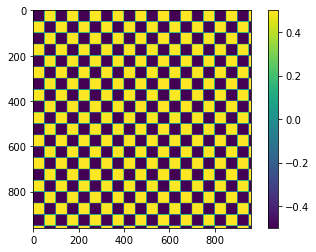

In [114]:
imshow(checker), colorbar()

(<matplotlib.image.AxesImage at 0x23acb517608>,
 <matplotlib.colorbar.Colorbar at 0x23acb469488>)

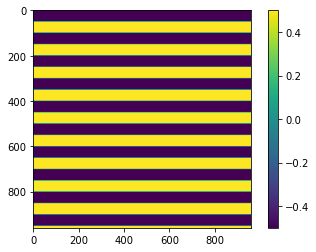

In [111]:
imshow(GY),colorbar()

In [106]:
GY

array([[-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       [-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       [-0.5, -0.5, -0.5, ..., -0.5, -0.5, -0.5],
       ...,
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5],
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5],
       [ 0.5,  0.5,  0.5, ...,  0.5,  0.5,  0.5]])